In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import py_deffields as pd

In [12]:
elastic_generator = pd.ElasticDeformation(alpha=4, sigma=8)
deformation_field = elastic_generator.generate((128, 128, 128))

In [13]:
deformation_field.shape

(128, 128, 128, 3)

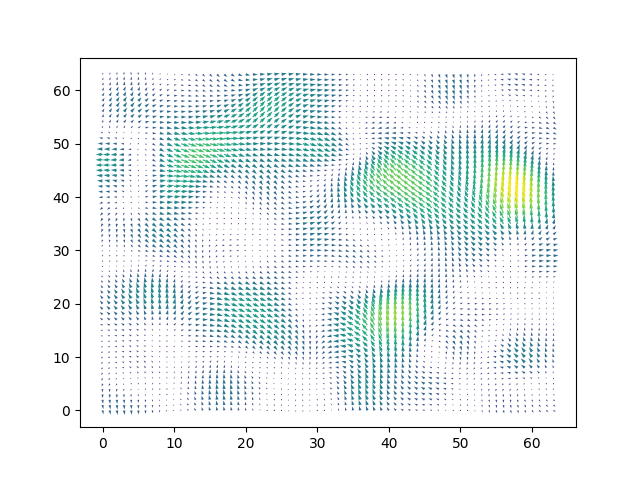

In [29]:
fig, ax = plt.subplots()

subsampling_factor: int = 2

ax.quiver(
    deformation_field[::subsampling_factor, ::subsampling_factor, 64, 0],
    deformation_field[::subsampling_factor, ::subsampling_factor, 64, 1],
    np.linalg.norm(
        deformation_field[::subsampling_factor, ::subsampling_factor, 64, :2],
        axis=-1,
    )
)

In [15]:
import ipywidgets as widgets
import einops

In [19]:
df = einops.rearrange(deformation_field, 'x y z d -> z y x d')

In [20]:
import enum

class AxisState(enum.Enum):
    ZYX = 'zyx'
    ZXY = 'zxy'
    YXZ = 'yxz'
    YZX = 'yzx'
    XZY = 'xzy'
    XYZ = 'xyz'


def _make_axis_dropdown():
    return widgets.Dropdown(
        options=[axis_state.value for axis_state in AxisState],
        value=AxisState.ZYX.value,
        description='Axis Order:',
    )


In [21]:
ddw = _make_axis_dropdown()
ddw

Dropdown(description='Axis Order:', options=('zyx', 'zxy', 'yxz', 'yzx', 'xzy', 'xyz'), value='zyx')

In [22]:

def _make_axis_selector() -> widgets.Dropdown:
    axis_selector = widgets.Dropdown(
        options={
            "XY": 2,
            "XZ": 1,
            "YZ": 0,
        },
        value=2,
        description="Axis:",
    )
    return axis_selector

In [23]:
from IPython.display import display
from py_deffields.visualization.quiver import *

In [24]:
generate_einops_pattern(AxisState.ZYX)

'z y x -> z y x'

In [33]:
def generate_vectorfield_component_selector(
    axis_state: AxisState,
) -> tuple[int]:
    axis_to_index = {'z': 0, 'y': 1, 'x': 2}
    return tuple(axis_to_index[axis] for axis in axis_state.value[1:])


generate_vectorfield_component_selector(AxisState.XYZ)

(1, 0)

In [49]:
spatial = (25, slice(None, None, 2), slice(None, None, 2))

selection = deformation_field[*spatial, np.array([0, 1])]
print(selection.shape)

index = 0

assert np.allclose(
    selection[index, ...],
    deformation_field[25, ::2, ::2, index],    
)

(2, 64, 64)
